# Tema 2: Componentes Fundamentales de un Agente



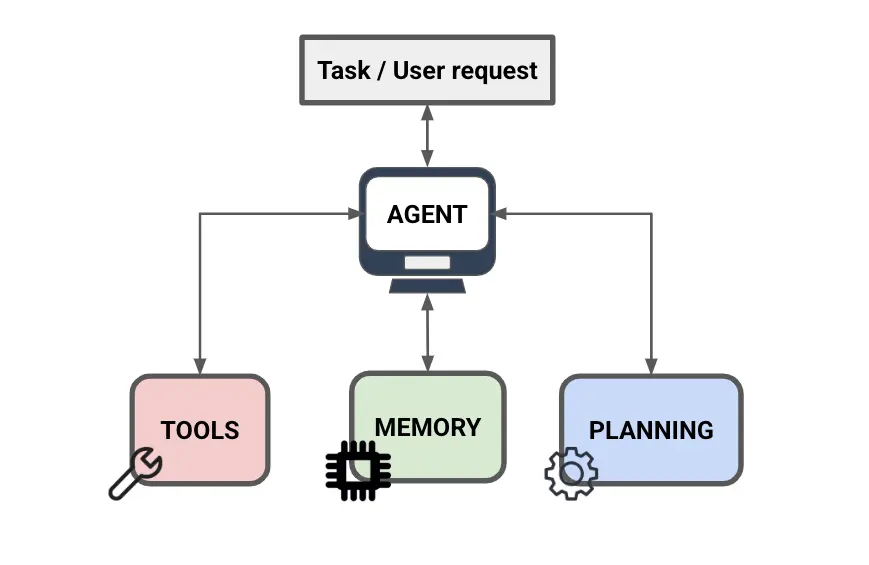

# 2.1 El Agent Core (LLM)

El **Agent Core** es el "cerebro" del agente: el modelo de lenguaje que realiza el razonamiento.

## Selección de Modelo

### Trade-off fundamental: Capabilities vs Cost vs Latency

```
                   Capabilities ↑
                        |
              GPT-4o   |   Claude Opus
                  \\    |    /
                   \\   |   /
        Claude ---- SWEET ---- GPT-4
        Sonnet      SPOT      Turbo
                   /   |   \\
                  /    |    \\
            GPT-3.5    |   Llama 3
                       |
Cost ←-----------------|------------------→ Latency
```

No existe el "modelo perfecto" - siempre hay trade-offs.

In [ ]:
# Setup
!pip install openai anthropic pandas matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.9/635.9 kB 7.4 MB/s eta 0:00:00


| Modelo | Capabilities | Cost ($/1M tokens) | Latency (ms) | Context Window | Function Calling |
|---|---:|---:|---:|---|---|
| GPT-4o | 95 | 5.0 | 800 | 128K | ✅ |
| Claude Opus 3.5 | 95 | 15.0 | 1200 | 200K | ✅ |
| GPT-4 Turbo | 90 | 10.0 | 1000 | 128K | ✅ |
| Claude Sonnet 3.5 | 90 | 3.0 | 600 | 200K | ✅ |
| GPT-3.5 Turbo | 75 | 0.5 | 400 | 16K | ✅ |
| Llama 3.1 70B | 80 | 0.0 | 300 | 128K | ⚠️ |
| Gemini Pro 1.5 | 88 | 7.0 | 700 | 1M | ✅ |

### Cuándo usar cada modelo

**GPT-4o / Claude Opus (Frontier models):**
- ✅ Tareas complejas de razonamiento
- ✅ Planning sofisticado
- ✅ Multi-step workflows críticos
- ❌ Alto costo
- ❌ Mayor latencia

**GPT-3.5 Turbo / Claude Haiku (Fast models):**
- ✅ Tareas simples y repetitivas
- ✅ Clasificación
- ✅ Extracción de información
- ✅ Bajo costo
- ✅ Baja latencia
- ❌ Capabilities limitadas

**Llama 3.1 / Mistral (Open-source):**
- ✅ Self-hosting (privacidad)
- ✅ Sin costo por token
- ✅ Fine-tuning completo
- ❌ Requiere infraestructura
- ❌ Capabilities menores

### Cuándo usar Reasoning Models (o1, Claude Extended Thinking)

**Reasoning models** usan más **test-time compute** para "pensar" antes de responder.

**Usar cuando:**
- ✅ Matemáticas complejas
- ✅ Coding difícil
- ✅ Razonamiento multi-paso
- ✅ Planning complejo
- ✅ Quality > Speed

**NO usar cuando:**
- ❌ Tareas simples (clasificación, extracción)
- ❌ Latencia crítica (<1s)
- ❌ Budget limitado (más caro)
- ❌ Creative writing (no necesita tanto razonamiento)

## Structured Outputs

Los agentes necesitan outputs **estructurados** para tomar decisiones programáticas.

### 1. JSON Mode

In [ ]:
import openai
import json
from google.colab import userdata
# Configurar API key

api_key = userdata.get('OPENAI_API_KEY')

# Initialize the OpenAI client
client = openai.OpenAI(api_key=api_key)

def extract_struct_output(texto: str) -> dict:
    """
    Extrae información estructurada usando JSON mode
    """
    response = client.chat.completions.create(
        model="gpt-4o", # Changed model to gpt-4o as gpt-4 is older
        messages=[
            {
                "role": "system",
                "content": "Extrae información y devuelve JSON con: nombre, empresa, email, telefono"
            },
            {
                "role": "user",
                "content": texto
            }
        ],
        response_format={"type": "json_object"}  # Fuerza JSON
    )

    return json.loads(response.choices[0].message.content)

# Ejemplo
texto = """
Hola, soy Fran de linkhub.
Puedes contactarme en franalguacil2@gmail.com o al +34 600 123 456
"""
print("Output real")
info = extract_struct_output(texto)
print(json.dumps(info, indent=2))

print("Output esperado:")
print(json.dumps({
    "nombre": "Juan Pérez",
    "empresa": "Acme Corp",
    "email": "juan@acme.com",
    "telefono": "+34 600 123 456"
}, indent=2))

Output real
{
  "nombre": "Fran",
  "empresa": "linkhub",
  "email": "franalguacil2@gmail.com",
  "telefono": "+34 600 123 456"
}
Output esperado:
{
  "nombre": "Juan P\u00e9rez",
  "empresa": "Acme Corp",
  "email": "juan@acme.com",
  "telefono": "+34 600 123 456"
}


### 2. Function Calling (Schema Enforcement)

Function calling garantiza que el output cumpla un **schema específico**.

In [ ]:
# Definir schema estricto
schema = {
    "type": "function",
    "function": {
        "name": "guardar_contacto",
        "description": "Guarda información de contacto",
        "parameters": {
            "type": "object",
            "properties": {
                "nombre": {
                    "type": "string",
                    "description": "Nombre completo"
                },
                "empresa": {
                    "type": "string",
                    "description": "Nombre de la empresa"
                },
                "email": {
                    "type": "string",
                    "pattern": "^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\\.[a-zA-Z]{2,}$"
                },
                "prioridad": {
                    "type": "string",
                    "enum": ["alta", "media", "baja"]  # Solo estos valores
                }
            },
            "required": ["nombre", "email", "prioridad"]  # Campos obligatorios
        }
    }
}

print("Schema enforcement garantiza:")
print("✅ Tipos correctos (string, number, boolean, etc.)")
print("✅ Campos requeridos presentes")
print("✅ Valores dentro de enums permitidos")
print("✅ Patterns (regex) cumplidos")

Schema enforcement garantiza:
✅ Tipos correctos (string, number, boolean, etc.)
✅ Campos requeridos presentes
✅ Valores dentro de enums permitidos
✅ Patterns (regex) cumplidos


## Context Window

El **context window** es la cantidad máxima de tokens que el modelo puede procesar.

### Límites por modelo (2026)

| Modelo | Context Window | Implicación |
|--------|----------------|-------------|
| GPT-3.5 Turbo | 16K tokens | ~12K palabras, ~30 páginas |
| GPT-4 Turbo | 128K tokens | ~96K palabras, ~240 páginas |
| Claude 3.5 | 200K tokens | ~150K palabras, ~400 páginas |
| Gemini 1.5 Pro | 1M tokens | ~750K palabras, ~2000 páginas |

### Implicaciones Arquitectónicas

In [ ]:
def estimar_tokens(texto: str) -> int:
    """
    Estimación rápida: ~1.3 tokens por palabra en inglés
    ~1.5 tokens por palabra en español
    """
    palabras = len(texto.split())
    return int(palabras * 1.5)  # Estimación conservadora

# Ejemplos
conversacion_corta = "Usuario: Hola\nAsistente: ¡Hola! ¿En qué puedo ayudarte?"
print(f"Conversación corta: ~{estimar_tokens(conversacion_corta)} tokens")

documento_largo = " ".join(["palabra"] * 50000)  # 50K palabras
print(f"Documento largo: ~{estimar_tokens(documento_largo)} tokens")

print("\n⚠️ Implicaciones:")
print("• GPT-3.5 (16K): Cabe conversación corta ✅")
print("• GPT-3.5 (16K): NO cabe documento largo ❌")
print("• Claude 3.5 (200K): Cabe documento largo ✅")
print("• Gemini 1.5 (1M): Cabe documento largo + mucho contexto ✅")

Conversación corta: ~12 tokens
Documento largo: ~75000 tokens

⚠️ Implicaciones:
• GPT-3.5 (16K): Cabe conversación corta ✅
• GPT-3.5 (16K): NO cabe documento largo ❌
• Claude 3.5 (200K): Cabe documento largo ✅
• Gemini 1.5 (1M): Cabe documento largo + mucho contexto ✅


**Decisiones arquitectónicas basadas en context window:**

```python
if context_needed < 16K:
    # Usar GPT-3.5 (más barato)
    model = "gpt-3.5-turbo"
elif context_needed < 128K:
    # Usar GPT-4 Turbo
    model = "gpt-4-turbo"
else:
    # Necesitas Claude o Gemini
    # O implementar chunking/summarization
    model = "claude-3-5-sonnet"
```

## Sampling Strategies

Los parámetros de sampling controlan **cómo** el modelo genera texto.

### Temperature: Determinismo vs Creatividad

### Guía práctica de Temperature para Agentes

| Temperature | Usar para | NO usar para |
|-------------|-----------|---------------|
| **0.0 - 0.3** | • Function calling<br>• Extracción de datos<br>• Clasificación<br>• Código | • Creative writing<br>• Brainstorming |
| **0.5 - 0.7** | • Conversación general<br>• Análisis<br>• Resúmenes | • Matemáticas exactas<br>• Tasks deterministas |
| **0.8 - 1.5** | • Creative writing<br>• Generación de ideas<br>• Storytelling | • Function calling<br>• Structured output |

In [ ]:
import openai
from google.colab import userdata


api_key = userdata.get('OPENAI_API_KEY')
client = openai.OpenAI(api_key=api_key)

# Ejemplo práctico: Temperature en un agente

def temperature_agent(task_type: str, query: str):
    """
    Ajusta temperature según el tipo de tarea
    """
    # Determinar temperature según tarea
    if task_type in ["classification", "extraction", "function_call"]:
        temperature = 0.0  # Determinista
        print(f"🎯 Tarea: {task_type} → Temperature: {temperature} (Determinista)")
    elif task_type in ["analysis", "conversation"]:
        temperature = 0.7  # Balanceado
        print(f"💬 Tarea: {task_type} → Temperature: {temperature} (Balanceado)")
    elif task_type in ["creative", "brainstorm"]:
        temperature = 1.2  # Creativo
        print(f"🎨 Tarea: {task_type} → Temperature: {temperature} (Creativo)")

    response = client.chat.completions.create(
         model="gpt-4",
         messages=[{"role": "user", "content": query}],
         temperature=temperature)

    return response.choices[0].message.content

# Ejemplos
temperature_agent("classification", "Clasifica este email como spam o no spam")
temperature_agent("conversation", "¿Cómo estás hoy?")
temperature_agent("creative", "Escribe un poema sobre el mar")

🎯 Tarea: classification → Temperature: 0.0 (Determinista)
💬 Tarea: conversation → Temperature: 0.7 (Balanceado)
🎨 Tarea: creative → Temperature: 1.2 (Creativo)


'Majestuoso mar, mar que enamoras,\nocéano de sal y sueños plenos,\ncon tu azul incomparable, siempre hermoso,\nme tienes cautivo, perdido en tus destellos.\n\nA cada ola que rompe en la orilla, revuelta,\ncada espuma y susurro tuyo, palabras lleva.\nNo hay lamento, alegría ni ternura oculta,\nque no descubras en las profundas cuevas.\n\nTu fuerza inmensa, bravura inigualable,\nmueves planetas con tus mareas gemelas,\ntejiendo bayas de casa en gris nubilado,\nanuncias tormentas en embravecidas olas bellas.\n\nReinas azul en el día, eres plata en la noche,\nespejo del sol, confidente de la luna,\ncon tu bruma y espuma acaricias el aire,\ndespidiendo ecos de canciones nunca escuchadas.\n\nEl firmamento entero cae ante ti sin nada que oponer,\nla estrella de mar y la aurora son testigos,\nde tus cuentos escritos en lenguaje del agua,\nheredados en caracoles y en los corales como abrigo.\n\nSeductora y misteriosa, joya de la tierra,\nposees en tus entrañas mágicos tesoros.\nMil secretos gu

### Otros parámetros de sampling

**Top-p (nucleus sampling):**
- Considera solo tokens cuya probabilidad acumulada sea ≤ p
- `top_p=0.9`: Considera el 90% más probable
- Alternativa a temperature

**Top-k:**
- Considera solo los k tokens más probables
- `top_k=50`: Solo considera los 50 tokens más probables
- Menos usado en LLMs modernos

**Frequency penalty:**
- Penaliza tokens que ya aparecieron
- Rango: 0 (sin penalización) a 2 (máxima)
- Útil para evitar repetición

**Presence penalty:**
- Penaliza tokens que ya aparecieron (sin importar frecuencia)
- Rango: 0 a 2
- Fomenta hablar de temas nuevos

---
# 2.2 Sistema de Memoria (Overview)

Los LLMs son **stateless** por defecto. Los agentes necesitan **memoria** para:
- Recordar conversaciones previas
- Mantener contexto a largo plazo
- Aprender de experiencias pasadas

## Tipos de Memoria

```
┌─────────────────────────────────────────┐
│         SISTEMA DE MEMORIA              │
└─────────────────────────────────────────┘
              │
    ┌─────────┼──────────┬────────────┐
    │         │          │            │
┌───▼───┐ ┌──▼────┐ ┌───▼──────┐ ┌──▼────────┐
│Working│ │Episodic│ │ Semantic │ │Procedural │
│Memory │ │ Memory │ │  Memory  │ │  Memory   │
└───────┘ └────────┘ └──────────┘ └───────────┘
```

### 1. Working Memory (Memoria de Trabajo)

**Qué es:** El context window del LLM - información inmediata y temporal.

**Características:**
- Rápida: está en el prompt
- Limitada: tamaño del context window
- Volátil: se pierde después de la conversación

**Gestión:**

In [ ]:
class WorkingMemory:
    """
    Gestión de working memory (context window)
    """
    def __init__(self, context_window_tokens=4000):
        self.messages = []
        self.context_window_tokens = context_window_tokens

    def add_message(self, role: str, content: str):
        """Añadir mensaje a la memoria"""
        self.messages.append({"role": role, "content": content})
        self._truncate_if_needed()

    def _estimate_tokens(self, text: str) -> int:
        """Estimación simple de tokens"""
        return int(len(text.split()) * 1.5)

    def _truncate_if_needed(self):
        """Sliding window: mantener solo mensajes recientes"""
        total_tokens = sum(self._estimate_tokens(m["content"]) for m in self.messages)

        while total_tokens > self.context_window_tokens and len(self.messages) > 1:
            idx_to_remove = None

            # Buscar el mensaje no-system más antiguo
            for i, msg in enumerate(self.messages):
                if msg["role"] != "system":
                    idx_to_remove = i
                    break

            # Si no hay nada más que borrar, salir
            if idx_to_remove is None:
                break

            removed = self.messages.pop(idx_to_remove)
            print(f"⚠️ Memoria llena. Removiendo mensaje antiguo: {removed['content'][:50]}...")

            total_tokens = sum(self._estimate_tokens(m["content"]) for m in self.messages)

    def get_context(self):
        """Obtener contexto para el LLM"""
        return self.messages


# Ejemplo
wm = WorkingMemory(context_window_tokens=600)
wm.add_message("system", "Eres un asistente útil")
wm.add_message("user", "Hola, ¿cómo estás?")
wm.add_message("assistant", "¡Hola! Estoy bien, gracias.")
wm.add_message("user", "Cuéntame sobre los agentes de IA " * 20)

print(f"\nMensajes en memoria: {len(wm.messages)}")
print(wm.get_context())


Mensajes en memoria: 4
[{'role': 'system', 'content': 'Eres un asistente útil'}, {'role': 'user', 'content': 'Hola, ¿cómo estás?'}, {'role': 'assistant', 'content': '¡Hola! Estoy bien, gracias.'}, {'role': 'user', 'content': 'Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA Cuéntame sobre los agentes de IA '}]


### 2. Episodic Memory (Memoria Episódica)

**Qué es:** Historial de interacciones pasadas.

**Características:**
- Persistente: se guarda en base de datos
- Específica: "qué pasó cuándo"
- Recuperable: se puede buscar y cargar

**Ejemplo:**

In [ ]:
from datetime import datetime
from typing import List, Dict

class EpisodicMemory:
    """
    Memoria episódica: historial de turnos
    """
    def __init__(self):
        self.turns = []

    def store_turn(self, interaction: Dict):
        """Guardar un turno de interacción"""
        turn = {
            "timestamp": datetime.now().isoformat(),
            "user_query": interaction["query"],
            "agent_response": interaction["response"],
            "tools_used": interaction.get("tools_used", []),
            "outcome": interaction.get("outcome", "success")
        }
        self.turns.append(turn)

    def retrieve_recent_turns(self, n: int = 5) -> List[Dict]:
        """Recuperar los N turnos más recientes"""
        return self.turns[-n:]

    def search_similar_turns(self, query: str) -> List[Dict]:
        """Buscar turnos similares (simplificado)"""
        # En producción: usar embeddings y vector similarity
        results = []
        for turn in self.turns:
            if query.lower() in turn["user_query"].lower():
                results.append(turn)
        return results


# Ejemplo
em = EpisodicMemory()

em.store_turn({
    "query": "¿Cuál es el precio de AAPL?",
    "response": "El precio de AAPL es $178.45",
    "tools_used": ["get_stock_price"],
    "outcome": "success"
})

em.store_turn({
    "query": "¿Y el de GOOGL?",
    "response": "El precio de GOOGL es $145.23",
    "tools_used": ["get_stock_price"],
    "outcome": "success"
})

print("Turnos recientes:")
for turn in em.retrieve_recent_turns(n=3):
    print(f"  • {turn['timestamp'][:19]}: {turn['user_query']}")

Turnos recientes:
  • 2026-04-21T08:14:27: ¿Cuál es el precio de AAPL?
  • 2026-04-21T08:14:27: ¿Y el de GOOGL?


### 3. Semantic Memory (Memoria Semántica)

**Qué es:** Conocimiento factual y conceptual - "saber qué".

**Características:**
- Factual: información sin contexto temporal
- Generalizable: aplica a múltiples situaciones
- Indexable: búsqueda semántica

**Implementación típica:** RAG (Retrieval-Augmented Generation)

In [ ]:
class SemanticMemory:
    """
    Memoria semántica: conocimiento factual
    (Versión simplificada - en producción usar vector DB)
    """
    def __init__(self):
        self.knowledge_base = {
            "Apple": {
                "symbol": "AAPL",
                "industry": "Technology",
                "founded": 1976,
                "ceo": "Tim Cook"
            },
            "Google": {
                "symbol": "GOOGL",
                "industry": "Technology",
                "founded": 1998,
                "ceo": "Sundar Pichai"
            }
        }

    def retrieve(self, query: str) -> Dict:
        """Recuperar conocimiento relevante"""
        # En producción: embedding similarity search
        for company, info in self.knowledge_base.items():
            if company.lower() in query.lower() or info['symbol'] in query:
                return info
        return {}

    def store(self, key: str, info: Dict):
        """Guardar nuevo conocimiento"""
        self.knowledge_base[key] = info

# Ejemplo
sm = SemanticMemory()
info = sm.retrieve("¿Quién es el CEO de Apple?")
print(f"CEO de Apple: {info.get('ceo', 'No encontrado')}")

# Agregar nuevo conocimiento
sm.store("Microsoft", {
    "symbol": "MSFT",
    "industry": "Technology",
    "ceo": "Satya Nadella"
})

print(f"\nEmpresas en knowledge base: {list(sm.knowledge_base.keys())}")

CEO de Apple: Tim Cook

Empresas en knowledge base: ['Apple', 'Google', 'Microsoft']


### 4. Procedural Memory (Memoria Procedimental)

**Qué es:** "Saber cómo" - habilidades y procedimientos aprendidos.

**Implementación:**
- **Few-shot examples:** Ejemplos en el prompt
- **Fine-tuning:** Ajustar pesos del modelo
- **Templates:** Patrones reutilizables

In [ ]:
class ProceduralMemory:
    """
    Memoria procedimental: habilidades aprendidas
    """
    def __init__(self):
        # Ejemplos de "cómo hacer" tareas
        self.examples = {
            "extract_email": [
                {
                    "input": "Contacta a juan@acme.com",
                    "output": "juan@acme.com"
                },
                {
                    "input": "Email: maria.garcia@empresa.es",
                    "output": "maria.garcia@empresa.es"
                }
            ],
            "classify_sentiment": [
                {
                    "input": "Este producto es excelente!",
                    "output": "positivo"
                },
                {
                    "input": "No me gusta nada, muy malo",
                    "output": "negativo"
                }
            ]
        }

    def get_examples(self, task: str) -> List[Dict]:
        """Obtener ejemplos para una tarea"""
        return self.examples.get(task, [])

    def add_example(self, task: str, input_text: str, output_text: str):
        """Aprender de un nuevo ejemplo"""
        if task not in self.examples:
            self.examples[task] = []

        self.examples[task].append({
            "input": input_text,
            "output": output_text
        })
        print(f"Aprendido nuevo ejemplo para '{task}'")

# Ejemplo
pm = ProceduralMemory()
examples = pm.get_examples("extract_email")
print("Ejemplos de extracción de email:")
for ex in examples:
    print(f"Input: {ex['input']} → Output: {ex['output']}")

# Aprender nuevo ejemplo
pm.add_example("extract_email", "Mi correo es pedro@test.com", "pedro@test.com")

Ejemplos de extracción de email:
  Input: Contacta a juan@acme.com → Output: juan@acme.com
  Input: Email: maria.garcia@empresa.es → Output: maria.garcia@empresa.es
✅ Aprendido nuevo ejemplo para 'extract_email'


### Integración de los 4 Tipos de Memoria

In [ ]:
class MemorySystem:
    """
    Sistema de memoria completo para un agente
    """
    def __init__(self):
        self.working = WorkingMemory()
        self.episodic = EpisodicMemory()
        self.semantic = SemanticMemory()
        self.procedural = ProceduralMemory()

    def process_interaction(self, user_query: str, agent_response: str, tools_used: List[str]):
        """Procesar una interacción completa"""
        # 1. Añadir a working memory
        self.working.add_message("user", user_query)
        self.working.add_message("assistant", agent_response)

        # 2. Guardar en episodic memory
        self.episodic.store_turn({
            'query': user_query,
            'response': agent_response,
            'tools_used': tools_used
        })

        print(f"💾 Interacción guardada en memoria")

    def get_relevant_context(self, current_query: str) -> Dict:
        """Obtener contexto relevante de todas las memorias"""
        return {
            "working_memory": self.working.get_context()[-3:],  # Últimos 3 mensajes
            "similar_episodes": self.episodic.search_similar_turns(current_query)[:2],
            "semantic_knowledge": self.semantic.retrieve(current_query),
            "examples": self.procedural.get_examples("general")[:2]
        }

# Ejemplo de uso
memory = MemorySystem()
memory.process_interaction(
    user_query="¿Precio de AAPL?",
    agent_response="$178.45",
    tools_used=["get_stock_price"]
)

context = memory.get_relevant_context("¿Quién es el CEO de Apple?")
print(f"\n📚 Contexto recuperado:")
print(f"  Working memory: {len(context['working_memory'])} mensajes")
print(f"  Episodios similares: {len(context['similar_episodes'])}")
print(f"  Conocimiento semántico: {'CEO' in str(context['semantic_knowledge'])}")

💾 Interacción guardada en memoria

📚 Contexto recuperado:
  Working memory: 2 mensajes
  Episodios similares: 0
  Conocimiento semántico: False


---
# 2.3 Interfaz de Herramientas (Tools)

Las **herramientas (tools)** son el puente entre el agente y el mundo exterior.

## ¿Qué son las herramientas?

**Definición:** Funciones que el agente puede llamar para:
- Obtener información (búsquedas, APIs)
- Realizar cálculos (matemáticas, procesamiento)
- Ejecutar acciones (enviar emails, crear tickets)

## Tool Calling / Function Calling

**Flujo:**

In [ ]:
# Ejemplo de tool calling completo

# 1. Definir la tool
def calcular_impuesto(precio: float, tasa: float = 0.21) -> dict:
    """
    Calcula el impuesto de un precio
    """
    impuesto = precio * tasa
    total = precio + impuesto

    return {
        "precio_base": precio,
        "tasa_impuesto": tasa,
        "impuesto": round(impuesto, 2),
        "total": round(total, 2)
    }

# 2. Definir el schema de la tool
tool_schema = {
    "type": "function",
    "function": {
        "name": "calcular_impuesto",
        "description": "Calcula el impuesto (IVA) de un precio",
        "parameters": {
            "type": "object",
            "properties": {
                "precio": {
                    "type": "number",
                    "description": "Precio base sin impuestos"
                },
                "tasa": {
                    "type": "number",
                    "description": "Tasa de impuesto (0.21 = 21%)",
                    "default": 0.21
                }
            },
            "required": ["precio"]
        }
    }
}

# 3. El agente llama la tool
resultado = calcular_impuesto(precio=100, tasa=0.21)
print("Resultado de la tool:")
print(json.dumps(resultado, indent=2))

Resultado de la tool:
{
  "precio_base": 100,
  "tasa_impuesto": 0.21,
  "impuesto": 21.0,
  "total": 121.0
}


## Categorías de Tools

### 1. Information Retrieval (Búsqueda de Información)

In [ ]:
# Ejemplos de tools de información

def search_web(query: str) -> dict:
    """Buscar en la web (simulado)"""
    return {
        "query": query,
        "results": [
            {"title": "Result 1", "snippet": "..."},
            {"title": "Result 2", "snippet": "..."}
        ]
    }

def query_database(sql: str) -> list:
    """Consultar base de datos (simulado)"""
    return [
        {"id": 1, "name": "Product A", "price": 100},
        {"id": 2, "name": "Product B", "price": 150}
    ]

def read_file(filepath: str) -> str:
    """Leer archivo (simulado)"""
    return "Contenido del archivo..."

print("✅ Tools de Information Retrieval definidas")

✅ Tools de Information Retrieval definidas


### 2. Computation (Cálculos y Procesamiento)

In [ ]:
# Ejemplos de tools de computación

def calculate(expression: str) -> float:
    """Calculadora (con eval - solo para demo, NO usar en producción)"""
    # En producción: usar biblioteca segura como sympy
    try:
        result = eval(expression, {"__builtins__": {}}, {})
        return result
    except:
        return "Error en la expresión"

def execute_python(code: str) -> str:
    """Ejecutar código Python (simulado - requiere sandbox real)"""
    # En producción: usar E2B, Modal, o Docker
    return f"Output de ejecutar: {code}"

def analyze_data(data: list) -> dict:
    """Análisis estadístico básico"""
    import statistics
    return {
        "mean": statistics.mean(data),
        "median": statistics.median(data),
        "stdev": statistics.stdev(data) if len(data) > 1 else 0
    }

# Test
print(f"Cálculo: 25 * 4 + 10 = {calculate('25 * 4 + 10')}")
print(f"Análisis: {analyze_data([10, 20, 30, 40, 50])}")

Cálculo: 25 * 4 + 10 = 110
Análisis: {'mean': 30, 'median': 30, 'stdev': 15.811388300841896}


### 3. Action (Acciones en el Mundo)

In [ ]:
# Ejemplos de tools de acción

def send_email(to: str, subject: str, body: str) -> dict:
    """Enviar email (simulado)"""
    return {
        "status": "sent",
        "to": to,
        "subject": subject,
        "timestamp": datetime.now().isoformat()
    }

def create_ticket(title: str, description: str, priority: str) -> dict:
    """Crear ticket en sistema (simulado)"""
    ticket_id = f"TICKET-{np.random.randint(1000, 9999)}"
    return {
        "ticket_id": ticket_id,
        "title": title,
        "priority": priority,
        "status": "open"
    }

def write_file(filepath: str, content: str) -> dict:
    """Escribir archivo (simulado)"""
    return {
        "status": "written",
        "filepath": filepath,
        "bytes": len(content)
    }

# Test
result = create_ticket(
    title="Bug en login",
    description="Los usuarios no pueden iniciar sesión",
    priority="high"
)
print(f"Ticket creado: {result['ticket_id']}")

Ticket creado: TICKET-3984


## Diseño Básico de Tools

### Principios de buen diseño:

1. **Documentación clara (para el LLM)**
2. **Parámetros bien definidos**
3. **Manejo de errores robusto**
4. **Outputs estructurados**
5. **Idempotencia cuando sea posible**

In [ ]:
import requests

def get_weather(city: str, units: str = "celsius") -> dict:
    """
    Obtiene el clima actual de una ciudad usando Open-Meteo.
    """
    if not city:
        return {"error": "City parameter is required"}

    if units not in ["celsius", "fahrenheit"]:
        return {"error": f"Invalid units: {units}. Use 'celsius' or 'fahrenheit'"}

    try:
        # 1) Geocodificar ciudad
        geo_url = "https://geocoding-api.open-meteo.com/v1/search"
        geo_params = {
            "name": city,
            "count": 1,
            "language": "es",
            "format": "json"
        }

        geo_response = requests.get(geo_url, params=geo_params, timeout=10)
        geo_response.raise_for_status()
        geo_data = geo_response.json()

        results = geo_data.get("results")
        if not results:
            return {"error": f"City not found: {city}"}

        location = results[0]
        latitude = location["latitude"]
        longitude = location["longitude"]
        resolved_name = location["name"]
        country = location.get("country", "")

        # 2) Consultar clima actual
        weather_url = "https://api.open-meteo.com/v1/forecast"
        weather_params = {
            "latitude": latitude,
            "longitude": longitude,
            "current": [
                "temperature_2m",
                "relative_humidity_2m",
                "weather_code",
                "wind_speed_10m"
            ],
            "temperature_unit": units,
            "wind_speed_unit": "kmh",
            "timezone": "auto"
        }

        weather_response = requests.get(weather_url, params=weather_params, timeout=10)
        weather_response.raise_for_status()
        weather_data = weather_response.json()

        current = weather_data.get("current")
        if not current:
            return {"error": f"Weather data not available for {city}"}

        # Traducción simple de weather_code
        weather_code_map = {
            0: "clear sky",
            1: "mainly clear",
            2: "partly cloudy",
            3: "overcast",
            45: "fog",
            48: "depositing rime fog",
            51: "light drizzle",
            53: "moderate drizzle",
            55: "dense drizzle",
            56: "light freezing drizzle",
            57: "dense freezing drizzle",
            61: "slight rain",
            63: "moderate rain",
            65: "heavy rain",
            66: "light freezing rain",
            67: "heavy freezing rain",
            71: "slight snow fall",
            73: "moderate snow fall",
            75: "heavy snow fall",
            77: "snow grains",
            80: "slight rain showers",
            81: "moderate rain showers",
            82: "violent rain showers",
            85: "slight snow showers",
            86: "heavy snow showers",
            95: "thunderstorm",
            96: "thunderstorm with slight hail",
            99: "thunderstorm with heavy hail"
        }

        return {
            "city": resolved_name,
            "country": country,
            "temperature": current.get("temperature_2m"),
            "units": units,
            "condition": weather_code_map.get(current.get("weather_code"), "unknown"),
            "humidity": current.get("relative_humidity_2m"),
            "wind_speed": current.get("wind_speed_10m"),
            "latitude": latitude,
            "longitude": longitude
        }

    except requests.Timeout:
        return {"error": "Request timed out"}
    except requests.RequestException as e:
        return {"error": f"API request failed: {str(e)}"}
    except Exception as e:
        return {"error": f"Failed to fetch weather: {str(e)}"}


# Test
print("✅ Caso correcto:")
print(get_weather("Madrid", "celsius"))

print("\n❌ Caso de error:")
print(get_weather("", "celsius"))

print("\n❌ Parámetro inválido:")
print(get_weather("Madrid", "kelvin"))

✅ Caso correcto:
{'city': 'Madrid', 'country': 'España', 'temperature': 18.1, 'units': 'celsius', 'condition': 'mainly clear', 'humidity': 46, 'wind_speed': 5.4, 'latitude': 40.4165, 'longitude': -3.70256}

❌ Caso de error:
{'error': 'City parameter is required'}

❌ Parámetro inválido:
{'error': "Invalid units: kelvin. Use 'celsius' or 'fahrenheit'"}


### Schema para la tool anterior

In [ ]:
weather_tool_schema = {
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Obtiene el clima actual de una ciudad. Usa esto cuando el usuario pregunte sobre el tiempo, temperatura, o condiciones climáticas.",
        "parameters": {
            "type": "object",
            "properties": {
                "city": {
                    "type": "string",
                    "description": "Nombre de la ciudad (ej: Madrid, Barcelona, Valencia)"
                },
                "units": {
                    "type": "string",
                    "enum": ["celsius", "fahrenheit"],
                    "description": "Unidades de temperatura. Usa 'celsius' para Europa.",
                    "default": "celsius"
                }
            },
            "required": ["city"]
        }
    }
}

print("Schema de la tool:")
print(json.dumps(weather_tool_schema, indent=2))

Schema de la tool:
{
  "type": "function",
  "function": {
    "name": "get_weather",
    "description": "Obtiene el clima actual de una ciudad. Usa esto cuando el usuario pregunte sobre el tiempo, temperatura, o condiciones clim\u00e1ticas.",
    "parameters": {
      "type": "object",
      "properties": {
        "city": {
          "type": "string",
          "description": "Nombre de la ciudad (ej: Madrid, Barcelona, Valencia)"
        },
        "units": {
          "type": "string",
          "enum": [
            "celsius",
            "fahrenheit"
          ],
          "description": "Unidades de temperatura. Usa 'celsius' para Europa.",
          "default": "celsius"
        }
      },
      "required": [
        "city"
      ]
    }
  }
}


---
# 2.4 Módulo de Planificación

El **módulo de planificación** determina cómo el agente descompone tareas complejas en pasos ejecutables.

## Planning Explícito vs Implícito

### Planning Implícito
**Qué es:** El modelo planifica "en su cabeza" sin producir un plan visible.

**Ejemplo:**

In [ ]:
def planning_implicito(objetivo: str) -> str:

    # El modelo recibe el objetivo y decide directamente qué hacer
    prompt = f"""
    Objetivo: {objetivo}

    ¿Qué acción deberías tomar ahora?
    Responde solo con la acción.
    """

    # response = llm.generate(prompt)
    # return response

    # Simulación
    return "search_web('últimas noticias sobre IA')"

# Ejemplo
objetivo = "Investiga las últimas tendencias en IA y escribe un resumen"
accion = planning_implicito(objetivo)
print(f"Acción decidida (implícitamente): {accion}")

print("\n✅ Ventajas del planning implícito:")
print(" • Rápido (menos tokens)")
print(" • Flexible (se adapta sobre la marcha)")
print("\n❌ Desventajas:")
print(" • Menos transparente")
print(" • Puede perderse en tareas complejas")
print(" • Difícil de debuggear")

Acción decidida (implícitamente): search_web('últimas noticias sobre IA')

✅ Ventajas del planning implícito:
 • Rápido (menos tokens)
 • Flexible (se adapta sobre la marcha)

❌ Desventajas:
 • Menos transparente
 • Puede perderse en tareas complejas
 • Difícil de debuggear


### Planning Explícito
**Qué es:** El modelo genera un plan completo antes de ejecutar.

In [ ]:
import json

def planning_explicito(objetivo: str) -> dict:
    """
    Planning explícito: genera plan completo antes de ejecutar
    """
    prompt = f"""
    Objetivo: {objetivo}

    Genera un plan detallado con pasos numerados.
    Output en JSON:
    {{
      "objetivo": "...",
      "pasos": [
        {{"numero": 1, "accion": "...", "razon": "..."}},
        ...
      ]
    }}
    """

    # response = llm.generate(prompt, response_format={"type": "json_object"})
    # plan = json.loads(response)

    # Simulación
    plan = {
        "objetivo": objetivo,
        "pasos": [
            {
                "numero": 1,
                "accion": "search_web('tendencias IA 2026')",
                "razon": "Obtener información actualizada"
            },
            {
                "numero": 2,
                "accion": "search_web('papers recientes IA')",
                "razon": "Complementar con investigación académica"
            },
            {
                "numero": 3,
                "accion": "analyze_and_synthesize()",
                "razon": "Procesar toda la información recopilada"
            },
            {
                "numero": 4,
                "accion": "write_summary()",
                "razon": "Generar el resumen final"
            }
        ]
    }

    return plan

# Ejemplo
objetivo = "Investiga las últimas tendencias en IA y escribe un resumen"
plan = planning_explicito(objetivo)

print("📋 Plan generado:")
print(f"Objetivo: {plan['objetivo']}")
print(f"\nPasos ({len(plan['pasos'])}):")
for paso in plan['pasos']:
    print(f"  {paso['numero']}. {paso['accion']}")
    print(f"     → {paso['razon']}")

print("\n✅ Ventajas del planning explícito:")
print("  • Transparente (se ve el plan)")
print("  • Mejor para tareas complejas")
print("  • Fácil de debuggear y modificar")
print("\n❌ Desventajas:")
print("  • Más lento (más tokens)")
print("  • Menos flexible (debe re-planificar)")
print("  • Puede sobre-planificar tareas simples")

📋 Plan generado:
Objetivo: Investiga las últimas tendencias en IA y escribe un resumen

Pasos (4):
  1. search_web('tendencias IA 2026')
     → Obtener información actualizada
  2. search_web('papers recientes IA')
     → Complementar con investigación académica
  3. analyze_and_synthesize()
     → Procesar toda la información recopilada
  4. write_summary()
     → Generar el resumen final

✅ Ventajas del planning explícito:
  • Transparente (se ve el plan)
  • Mejor para tareas complejas
  • Fácil de debuggear y modificar

❌ Desventajas:
  • Más lento (más tokens)
  • Menos flexible (debe re-planificar)
  • Puede sobre-planificar tareas simples


## Task Decomposition

**Descomposición de tareas:** Dividir una tarea compleja en sub-tareas manejables.

### Descomposición Jerárquica

In [ ]:
class TaskDecomposer:
    """
    Descompone tareas complejas en sub-tareas jerárquicas
    """

    def decompose(self, task: str, max_depth: int = 2) -> dict:
        """
        Descompone una tarea en sub-tareas jerárquicas
        """
        # En producción: usar LLM para la descomposición
        # Aquí simulamos la respuesta

        if "organizar evento" in task.lower():
            return {
                "tarea_principal": task,
                "sub_tareas": [
                    {
                        "id": "1",
                        "descripcion": "Planificación inicial",
                        "sub_tareas": [
                            {"id": "1.1", "descripcion": "Definir objetivos del evento"},
                            {"id": "1.2", "descripcion": "Establecer presupuesto"},
                            {"id": "1.3", "descripcion": "Seleccionar fecha y lugar"}
                        ]
                    },
                    {
                        "id": "2",
                        "descripcion": "Logística",
                        "sub_tareas": [
                            {"id": "2.1", "descripcion": "Contratar catering"},
                            {"id": "2.2", "descripcion": "Reservar equipamiento AV"},
                            {"id": "2.3", "descripcion": "Organizar transporte"}
                        ]
                    },
                    {
                        "id": "3",
                        "descripcion": "Marketing y comunicación",
                        "sub_tareas": [
                            {"id": "3.1", "descripcion": "Diseñar invitaciones"},
                            {"id": "3.2", "descripcion": "Enviar invitaciones"},
                            {"id": "3.3", "descripcion": "Gestionar confirmaciones"}
                        ]
                    }
                ]
            }

        return {"tarea_principal": task, "sub_tareas": []}

    def print_tree(self, decomposition: dict, indent: int = 0):
        """
        Imprime el árbol de tareas
        """
        if indent == 0:
            print(f"📋 {decomposition['tarea_principal']}")

        for sub in decomposition.get('sub_tareas', []):
            print("  " * (indent + 1) + f"└─ {sub['id']}. {sub['descripcion']}")
            if 'sub_tareas' in sub and sub['sub_tareas']:
                for subsub in sub['sub_tareas']:
                    print("  " * (indent + 2) + f"└─ {subsub['id']}. {subsub['descripcion']}")

# Ejemplo
decomposer = TaskDecomposer()
tarea = "Organizar evento de lanzamiento de producto"
resultado = decomposer.decompose(tarea)
decomposer.print_tree(resultado)

📋 Organizar evento de lanzamiento de producto
  └─ 1. Planificación inicial
    └─ 1.1. Definir objetivos del evento
    └─ 1.2. Establecer presupuesto
    └─ 1.3. Seleccionar fecha y lugar
  └─ 2. Logística
    └─ 2.1. Contratar catering
    └─ 2.2. Reservar equipamiento AV
    └─ 2.3. Organizar transporte
  └─ 3. Marketing y comunicación
    └─ 3.1. Diseñar invitaciones
    └─ 3.2. Enviar invitaciones
    └─ 3.3. Gestionar confirmaciones


## Re-planning Dinámico

A veces el plan inicial no funciona - el agente debe **re-planificar**.

### Cuándo Re-planificar

In [ ]:
class DynamicPlanner:
    """
    Planificador que puede adaptarse cuando las cosas salen mal
    """

    def __init__(self):
        self.plan = None
        self.executed_steps = []
        self.failures = []

    def should_replan(self, step_result: dict) -> bool:
        """
        Decide si debe re-planificar basado en el resultado
        """
        # Razones para re-planificar:
        reasons = []

        # 1. El paso falló
        if step_result.get('status') == 'failed':
            reasons.append("Paso falló")

        # 2. El resultado es inesperado
        if step_result.get('unexpected') == True:
            reasons.append("Resultado inesperado")

        # 3. Nueva información cambia el contexto
        if step_result.get('context_changed') == True:
            reasons.append("Contexto cambió")

        # 4. Demasiados fallos consecutivos
        if len(self.failures) >= 3:
            reasons.append("Demasiados fallos consecutivos")

        if reasons:
            print(f"\n⚠️ Re-planning necesario: {', '.join(reasons)}")
            return True

        return False

    def replan(self, original_goal: str, current_state: dict, failure_info: dict) -> dict:
        """
        Genera un nuevo plan considerando el estado actual y fallos previos
        """
        print("\n🔄 Generando nuevo plan...")

        # En producción: usar LLM para generar plan alternativo
        new_plan = {
            "objetivo": original_goal,
            "razon_replan": failure_info.get('razon', 'Estrategia alternativa'),
            "pasos": [
                {"numero": 1, "accion": "try_alternative_approach()"},
                {"numero": 2, "accion": "verify_success()"}
            ]
        }

        self.plan = new_plan
        return new_plan

# Ejemplo de uso
planner = DynamicPlanner()

# Simular fallo
step_result = {
    'status': 'failed',
    'error': 'API timeout',
    'unexpected': True
}

if planner.should_replan(step_result):
    new_plan = planner.replan(
        original_goal="Obtener datos de mercado",
        current_state={"attempts": 1},
        failure_info={'razon': 'API principal no disponible'}
    )
    print(f"\n✅ Nuevo plan:")
    for paso in new_plan['pasos']:
        print(f"  {paso['numero']}. {paso['accion']}")


⚠️ Re-planning necesario: Paso falló, Resultado inesperado

🔄 Generando nuevo plan...

✅ Nuevo plan:
  1. try_alternative_approach()
  2. verify_success()


### Estrategias de Adaptación

In [ ]:
class AdaptationStrategies:
    """
    Diferentes estrategias para adaptar el plan
    """

    @staticmethod
    def retry_with_backoff(step: dict, attempt: int) -> dict:
        """Reintentar con espera exponencial"""
        import time
        wait_time = 2 ** attempt  # 2, 4, 8, 16 segundos...
        print(f"♻️ Reintento #{attempt} después de {wait_time}s")
        # time.sleep(wait_time)
        return step

    @staticmethod
    def fallback_to_alternative(step: dict) -> dict:
        """Usar método alternativo"""
        print(f"🔀 Fallback: Usando método alternativo")

        alternatives = {
            "search_api_primary": "search_api_backup",
            "database_query": "cache_lookup",
            "external_api": "local_computation"
        }

        original = step.get('accion', '')
        for primary, backup in alternatives.items():
            if primary in original:
                step['accion'] = backup
                break

        return step

    @staticmethod
    def skip_and_continue(step: dict, plan: list) -> list:
        """Saltar paso fallido y continuar"""
        print(f"⏭️ Saltando paso: {step.get('accion')}")
        # Verificar si pasos siguientes dependen de este
        # En producción: análisis de dependencias más sofisticado
        return [s for s in plan if s != step]

    @staticmethod
    def escalate_to_human(step: dict, error: str) -> dict:
        """Escalar a humano cuando el agente no puede resolver"""
        print(f"👤 Escalando a humano: {error}")
        return {
            "status": "human_intervention_required",
            "step": step,
            "error": error,
            "message": "Este paso requiere intervención humana"
        }

# Demo de estrategias
strategies = AdaptationStrategies()

print("📚 Estrategias de adaptación disponibles:\n")

step = {"accion": "search_api_primary('data')"}

# 1. Retry
strategies.retry_with_backoff(step, attempt=2)

# 2. Fallback
strategies.fallback_to_alternative(step.copy())

# 3. Skip
plan = [step, {"accion": "process_results()"}]
strategies.skip_and_continue(step, plan)

# 4. Escalate
strategies.escalate_to_human(step, "API credentials expired")

📚 Estrategias de adaptación disponibles:

♻️ Reintento #2 después de 4s
🔀 Fallback: Usando método alternativo
⏭️ Saltando paso: search_api_primary('data')
👤 Escalando a humano: API credentials expired


{'status': 'human_intervention_required',
 'step': {'accion': "search_api_primary('data')"},
 'error': 'API credentials expired',
 'message': 'Este paso requiere intervención humana'}

---
# 2.5 Orquestación y Control

La **orquestación** coordina todos los componentes del agente en un loop coherente.

## Agent Loop Básico: Observe → Think → Act

```
┌──────────────────────────────────┐
│    AGENT LOOP (Ciclo Continuo)  │
└──────────────────────────────────┘
              │
              ▼
    ┌─────────────────┐
    │   1. OBSERVE    │  ← Percibir estado actual
    │   (Percepción)  │
    └────────┬────────┘
             │
             ▼
    ┌─────────────────┐
    │   2. THINK      │  ← Razonar sobre qué hacer
    │  (Razonamiento) │
    └────────┬────────┘
             │
             ▼
    ┌─────────────────┐
    │   3. ACT        │  ← Ejecutar acción
    │   (Acción)      │
    └────────┬────────┘
             │
             ▼
        ¿Objetivo
        alcanzado?
         /      \\
       No        Sí
       │          │
       │          ▼
       │       (FIN)
       │
       └──────(loop)───┐
                       │
                       ▼
               (volver a OBSERVE)
```

In [ ]:
class AgentLoop:
    """
    Implementación del loop básico de un agente
    Observe → Think → Act
    """

    def __init__(self, llm, tools, memory):
        self.llm = llm
        self.tools = tools
        self.memory = memory
        self.state = {}
        self.iteration = 0

    def observe(self) -> dict:
        observation = {
            "iteration": self.iteration,
            "memory_context": self.memory.get_context(),
            "available_tools": list(self.tools.keys()),
            "current_state": self.state.copy()
        }

        print(f"\nOBSERVE (Iteración {self.iteration}):")
        print(f"Estado actual: {self.state}")

        return observation

    def think(self, observation: dict, goal: str) -> dict:
        """
        Razonar
        """
        # Construir prompt para el LLM
        prompt = f"""
        Objetivo: {goal}
        Estado actual: {observation['current_state']}
        Iteración: {observation['iteration']}

        Herramientas disponibles: {observation['available_tools']}

        Piensa: ¿Qué deberías hacer ahora para avanzar hacia el objetivo?
        """

        # En producción: llamar al LLM
        # thought = self.llm.generate(prompt)

        # Simulación
        thought = {
            "reasoning": "Necesito buscar información sobre el objetivo",
            "next_action": "search",
            "next_action_params": {"query": "information about goal"}
        }

        print(f"\n🧠 THINK:")
        print(f"Razonamiento: {thought['reasoning']}")
        print(f"Acción decidida: {thought['next_action']}")

        return thought

    def act(self, thought: dict) -> dict:
        """
        Ejecutar la acción decidida
        """
        action = thought['next_action']
        params = thought.get('next_action_params', {})

        print(f"\nACT:")
        print(f"Ejecutando: {action}({params})")

        # Ejecutar la tool
        if action in self.tools:
            result = self.tools[action](**params)
        else:
            result = {"error": f"Tool '{action}' not found"}

        # Actualizar estado
        self.state['last_action'] = action
        self.state['last_result'] = result

        print(f"   Resultado: {result}")

        return result

    def run(self, goal: str, max_iterations: int = 10) -> dict:
        """
        Ejecutar el loop completo
        """
        print(f"\n{'='*60}")
        print(f"OBJETIVO: {goal}")
        print(f"{'='*60}")

        for self.iteration in range(max_iterations):
            # 1. Observe
            observation = self.observe()

            # 2. Think
            thought = self.think(observation, goal)

            # 3. Act
            result = self.act(thought)

            # Check if goal achieved
            if self.goal_achieved(goal, result):
                print(f"\nOBJETIVO ALCANZADO en {self.iteration + 1} iteraciones")
                return {"status": "success", "iterations": self.iteration + 1}

            # Small delay for readability
            # import time
            # time.sleep(0.5)

        print(f"\n⚠️ Máximo de iteraciones alcanzado sin completar objetivo")
        return {"status": "max_iterations", "iterations": max_iterations}

    def goal_achieved(self, goal: str, last_result: dict) -> bool:
        """
        Verificar si el objetivo se alcanzó
        """
        # En producción: usar LLM para verificar
        # Por ahora, simulamos que se alcanza después de 3 iteraciones
        return self.iteration >= 2

# Ejemplo de uso
tools = {
    "search": lambda query: {"results": ["resultado 1", "resultado 2"]},
    "analyze": lambda data: {"summary": "análisis completo"}
}

memory = type('Memory', (), {'get_context': lambda self: []})()

agent = AgentLoop(llm=None, tools=tools, memory=memory)
result = agent.run(goal="Investigar tendencias de mercado", max_iterations=5)


OBJETIVO: Investigar tendencias de mercado

OBSERVE (Iteración 0):
Estado actual: {}

🧠 THINK:
Razonamiento: Necesito buscar información sobre el objetivo
Acción decidida: search

ACT:
Ejecutando: search({'query': 'information about goal'})
   Resultado: {'results': ['resultado 1', 'resultado 2']}

OBSERVE (Iteración 1):
Estado actual: {'last_action': 'search', 'last_result': {'results': ['resultado 1', 'resultado 2']}}

🧠 THINK:
Razonamiento: Necesito buscar información sobre el objetivo
Acción decidida: search

ACT:
Ejecutando: search({'query': 'information about goal'})
   Resultado: {'results': ['resultado 1', 'resultado 2']}

OBSERVE (Iteración 2):
Estado actual: {'last_action': 'search', 'last_result': {'results': ['resultado 1', 'resultado 2']}}

🧠 THINK:
Razonamiento: Necesito buscar información sobre el objetivo
Acción decidida: search

ACT:
Ejecutando: search({'query': 'information about goal'})
   Resultado: {'results': ['resultado 1', 'resultado 2']}

OBJETIVO ALCANZADO en

## State Management

El **estado** del agente contiene toda la información necesaria para tomar decisiones.

In [ ]:
from typing import Any, Dict, List
from datetime import datetime

class AgentState:

    def __init__(self):
        self.state = {
            "created_at": datetime.now().isoformat(),
            "goal": None,
            "status": "idle",  # idle, thinking, acting, success, failed
            "iterations": 0,
            "actions_taken": [],
            "observations": [],
            "errors": [],
            "metadata": {}
        }

    def set_goal(self, goal: str):
        """Establecer objetivo"""
        self.state['goal'] = goal
        self.state['status'] = 'active'

    def add_action(self, action: str, params: Dict, result: Any):
        """Registrar acción ejecutada"""
        self.state['actions_taken'].append({
            "timestamp": datetime.now().isoformat(),
            "action": action,
            "params": params,
            "result": result
        })
        self.state['iterations'] += 1

    def add_observation(self, observation: str):
        """Registrar observación"""
        self.state['observations'].append({
            "timestamp": datetime.now().isoformat(),
            "content": observation
        })

    def add_error(self, error: str, context: Dict = None):
        """Registrar error"""
        self.state['errors'].append({
            "timestamp": datetime.now().isoformat(),
            "error": error,
            "context": context or {}
        })

    def get_state(self) -> Dict:
        """Obtener estado actual"""
        return self.state.copy()

    def save_checkpoint(self, checkpoint_id: str):
        """Guardar checkpoint del estado"""
        # En producción: guardar en DB
        checkpoint = self.state.copy()
        checkpoint['checkpoint_id'] = checkpoint_id
        print(f"💾 Checkpoint guardado: {checkpoint_id}")
        return checkpoint

    def restore_checkpoint(self, checkpoint: Dict):
        """Restaurar desde checkpoint"""
        self.state = checkpoint.copy()
        print(f"Estado restaurado desde: {checkpoint.get('checkpoint_id')}")

# Ejemplo
state = AgentState()
state.set_goal("Analizar datos de ventas")
state.add_action("query_database", {"table": "sales"}, {"rows": 100})
state.add_observation("Datos recuperados exitosamente")

print("Estado actual del agente:")
current_state = state.get_state()
print(f"Objetivo: {current_state['goal']}")
print(f"Status: {current_state['status']}")
print(f"Iteraciones: {current_state['iterations']}")
print(f"Acciones: {len(current_state['actions_taken'])}")
print(f"Observaciones: {len(current_state['observations'])}")

# Guardar checkpoint
checkpoint = state.save_checkpoint("checkpoint_1")

Estado actual del agente:
Objetivo: Analizar datos de ventas
Status: active
Iteraciones: 1
Acciones: 1
Observaciones: 1
💾 Checkpoint guardado: checkpoint_1


## Error Handling y Recovery

Los agentes deben manejar errores de forma robusta.

### Tipos de Errores

In [ ]:
from enum import Enum

class ErrorType(Enum):
    """Tipos de errores que puede encontrar un agente"""
    TOOL_EXECUTION_FAILED = "tool_execution_failed"  # Tool falló al ejecutar
    TOOL_NOT_FOUND = "tool_not_found"  # Tool no existe
    INVALID_PARAMETERS = "invalid_parameters"  # Parámetros incorrectos
    TIMEOUT = "timeout"  # Operación tardó demasiado
    RATE_LIMIT = "rate_limit"  # API rate limit excedido
    AUTHENTICATION_ERROR = "authentication_error"  # Credenciales inválidas
    NETWORK_ERROR = "network_error"  # Problema de red
    UNEXPECTED_RESULT = "unexpected_result"  # Resultado no esperado
    LLM_ERROR = "llm_error"  # Error del modelo de lenguaje

class ErrorRecoveryStrategy(Enum):
    """Estrategias de recuperación"""
    RETRY = "retry"  # Reintentar la operación
    FALLBACK = "fallback"  # Usar método alternativo
    SKIP = "skip"  # Saltar y continuar
    ESCALATE = "escalate"  # Escalar a humano
    ABORT = "abort"  # Abortar completamente

print("Tipos de errores manejados:")
for error_type in ErrorType:
    print(f"  • {error_type.value}")

print("\nEstrategias de recuperación:")
for strategy in ErrorRecoveryStrategy:
    print(f"  • {strategy.value}")

Tipos de errores manejados:
  • tool_execution_failed
  • tool_not_found
  • invalid_parameters
  • timeout
  • rate_limit
  • authentication_error
  • network_error
  • unexpected_result
  • llm_error

Estrategias de recuperación:
  • retry
  • fallback
  • skip
  • escalate
  • abort


### Implementación de Error Handler

In [ ]:
class ErrorHandler:
    """
    Maneja errores y determina estrategia de recuperación
    """

    def __init__(self, max_retries: int = 3):
        self.max_retries = max_retries
        self.retry_count = {}

    def handle_error(self, error_type: ErrorType, context: Dict) -> ErrorRecoveryStrategy:
        """
        Determina la estrategia de recuperación según el tipo de error
        """
        action = context.get('action', 'unknown')

        # Inicializar contador de reintentos si no existe
        if action not in self.retry_count:
            self.retry_count[action] = 0

        print(f"\n🔴 ERROR: {error_type.value}")
        print(f"Contexto: {context}")

        # Decidir estrategia según tipo de error
        if error_type == ErrorType.TOOL_NOT_FOUND:
            print(" → Estrategia: ABORT (tool no existe)")
            return ErrorRecoveryStrategy.ABORT

        elif error_type == ErrorType.INVALID_PARAMETERS:
            print(" → Estrategia: ABORT (parámetros inválidos)")
            return ErrorRecoveryStrategy.ABORT

        elif error_type == ErrorType.RATE_LIMIT:
            if self.retry_count[action] < self.max_retries:
                self.retry_count[action] += 1
                print(f" → Estrategia: RETRY (intento {self.retry_count[action]}/{self.max_retries})")
                return ErrorRecoveryStrategy.RETRY
            else:
                print(" → Estrategia: ESCALATE (demasiados reintentos)")
                return ErrorRecoveryStrategy.ESCALATE

        elif error_type == ErrorType.NETWORK_ERROR:
            if self.retry_count[action] < self.max_retries:
                self.retry_count[action] += 1
                print(f" → Estrategia: RETRY (intento {self.retry_count[action]}/{self.max_retries})")
                return ErrorRecoveryStrategy.RETRY
            else:
                print(" → Estrategia: FALLBACK (usar método alternativo)")
                return ErrorRecoveryStrategy.FALLBACK

        elif error_type == ErrorType.TIMEOUT:
            print(" → Estrategia: FALLBACK o SKIP")
            return ErrorRecoveryStrategy.FALLBACK

        elif error_type == ErrorType.AUTHENTICATION_ERROR:
            print(" → Estrategia: ESCALATE (requiere credenciales)")
            return ErrorRecoveryStrategy.ESCALATE

        elif error_type == ErrorType.UNEXPECTED_RESULT:
            print(" → Estrategia: SKIP (resultado inesperado pero continuar)")
            return ErrorRecoveryStrategy.SKIP

        else:
            # Default: retry si no hemos excedido límite
            if self.retry_count[action] < self.max_retries:
                self.retry_count[action] += 1
                return ErrorRecoveryStrategy.RETRY
            return ErrorRecoveryStrategy.ESCALATE

# Ejemplo de uso
handler = ErrorHandler(max_retries=3)

# Simular diferentes errores
handler.handle_error(
    ErrorType.RATE_LIMIT,
    {"action": "api_call", "endpoint": "/data"}
)

handler.handle_error(
    ErrorType.TOOL_NOT_FOUND,
    {"action": "unknown_tool", "params": {}}
)

handler.handle_error(
    ErrorType.AUTHENTICATION_ERROR,
    {"action": "secure_api_call", "user": "agent_1"}
)


🔴 ERROR: rate_limit
   Contexto: {'action': 'api_call', 'endpoint': '/data'}
   → Estrategia: RETRY (intento 1/3)

🔴 ERROR: tool_not_found
   Contexto: {'action': 'unknown_tool', 'params': {}}
   → Estrategia: ABORT (tool no existe)

🔴 ERROR: authentication_error
   Contexto: {'action': 'secure_api_call', 'user': 'agent_1'}
   → Estrategia: ESCALATE (requiere credenciales)


<ErrorRecoveryStrategy.ESCALATE: 'escalate'>

## Stopping Conditions

El agente debe saber **cuándo detenerse**.

In [ ]:
class StoppingConditions:
    """
    Verifica condiciones de parada del agente
    """

    def __init__(self,
                 max_iterations: int = 10,
                 timeout_seconds: int = 300,
                 error_threshold: int = 5):
        self.max_iterations = max_iterations
        self.timeout_seconds = timeout_seconds
        self.error_threshold = error_threshold
        self.start_time = None

    def start(self):
        """Iniciar temporizador"""
        self.start_time = datetime.now()

    def should_stop(self, state: Dict) -> tuple[bool, str]:
        """
        Verifica si el agente debe detenerse

        Returns:
            (should_stop: bool, reason: str)
        """
        # 1. Objetivo alcanzado
        if state.get('status') == 'success':
            return True, "✅ Goal achieved"

        # 2. Máximo de iteraciones
        if state.get('iterations', 0) >= self.max_iterations:
            return True, f"⚠️ Max iterations reached ({self.max_iterations})"

        # 3. Timeout
        if self.start_time:
            elapsed = (datetime.now() - self.start_time).total_seconds()
            if elapsed >= self.timeout_seconds:
                return True, f"⏱️ Timeout ({self.timeout_seconds}s)"

        # 4. Demasiados errores
        if len(state.get('errors', [])) >= self.error_threshold:
            return True, f"❌ Error threshold exceeded ({self.error_threshold})"

        # 5. Error crítico
        if state.get('status') == 'failed':
            return True, "❌ Critical failure"

        # 6. Sin progreso (stuck)
        if self._is_stuck(state):
            return True, "🔄 No progress detected (stuck)"

        return False, ""

    def _is_stuck(self, state: Dict) -> bool:
        """
        Detecta si el agente está atascado (repitiendo acciones sin progreso)
        """
        actions = state.get('actions_taken', [])

        if len(actions) < 3:
            return False

        # Verificar si las últimas 3 acciones son idénticas
        last_3 = [a['action'] for a in actions[-3:]]
        if len(set(last_3)) == 1:  # Todas iguales
            print(f"   ⚠️ Detectado loop: acción '{last_3[0]}' repetida 3 veces")
            return True

        return False

# Ejemplo de uso
stopping = StoppingConditions(max_iterations=5, timeout_seconds=60, error_threshold=3)
stopping.start()

# Simular diferentes estados
test_states = [
    {"status": "active", "iterations": 2, "errors": []},
    {"status": "active", "iterations": 6, "errors": []},
    {"status": "success", "iterations": 3, "errors": []},
    {"status": "active", "iterations": 2, "errors": [1, 2, 3, 4]}
]

print("\nPrueba de condiciones de parada:\n")
for i, state in enumerate(test_states, 1):
    should_stop, reason = stopping.should_stop(state)
    print(f"Estado {i}: {state}")
    if should_stop:
        print(f"  🛑 STOP: {reason}")
    else:
        print(f"  ▶️ CONTINUE")
    print()


Prueba de condiciones de parada:

Estado 1: {'status': 'active', 'iterations': 2, 'errors': []}
  ▶️ CONTINUE

Estado 2: {'status': 'active', 'iterations': 6, 'errors': []}
  🛑 STOP: ⚠️ Max iterations reached (5)

Estado 3: {'status': 'success', 'iterations': 3, 'errors': []}
  🛑 STOP: ✅ Goal achieved

Estado 4: {'status': 'active', 'iterations': 2, 'errors': [1, 2, 3, 4]}
  🛑 STOP: ❌ Error threshold exceeded (3)




# Construir un Agente ReAct Simple

## Objetivo
Implementar un agente completo que use el patrón **ReAct** (Reasoning + Acting) integrando todos los componentes aprendidos.

## Componentes a integrar:
1. ✅ Agent Core (LLM)
2. ✅ Memoria
3. ✅ Tools
4. ✅ Planning
5. ✅ Orquestación (loop)
6. ✅ Error handling
7. ✅ Stopping conditions

In [ ]:
import json
import re
from typing import Dict, Any
from openai import OpenAI


class ReActAgent:
    """
    ReAct = Reasoning (Thought) + Acting (Action) + Observation
    """

    def __init__(
        self,
        tools: Dict[str, callable],
        tool_descriptions: Dict[str, str],
        model: str = "gpt-4o",
        max_iterations: int = 10,
        api_key: str | None = None
    ):
        self.tools = tools
        self.tool_descriptions = tool_descriptions
        self.model = model
        self.client = OpenAI(api_key=api_key)

        # Componentes reutilizados
        self.state = AgentState()
        self.error_handler = ErrorHandler()
        self.stopping = StoppingConditions(max_iterations=max_iterations)

        # Historial
        self.react_history = []

    def run(self, goal: str, verbose: bool = True) -> Dict[str, Any]:
        """
        Ejecutar el agente ReAct
        """
        if verbose:
            print(f"\n{'='*70}")
            print(f"OBJETIVO: {goal}")
            print(f"{'='*70}\n")

        self.state.set_goal(goal)
        self.stopping.start()

        iteration = 0

        while True:
            iteration += 1

            if verbose:
                print(f"\n{'─'*70}")
                print(f"🔄 Iteración {iteration}")
                print(f"{'─'*70}")

            # THOUGHT: el LLM decide qué hacer
            thought = self.think(goal, verbose)

            # ACTION: ejecutar tool o finalizar
            action_result = self.act(thought, goal, verbose)

            # OBSERVATION
            observation = self.observe(action_result, verbose)

            # Guardar en historial ReAct
            self.react_history.append({
                "iteration": iteration,
                "thought": thought,
                "action": action_result.get("action"),
                "observation": observation
            })

            # Verificar condiciones de parada
            should_stop, reason = self.stopping.should_stop(self.state.get_state())

            if should_stop:
                if verbose:
                    print(f"\n{'='*70}")
                    print(f"🛑 {reason}")
                    print(f"{'='*70}")
                break

        return self.generate_summary(verbose)

    def think(self, goal: str, verbose: bool = True) -> Dict[str, Any]:
        """
        THOUGHT: el LLM decide la siguiente acción en JSON.
        """
        state_snapshot = self.state.get_state()
        available_tools = list(self.tools.keys())

        tool_catalog = "\n".join(
            f"- {name}: {self.tool_descriptions.get(name, 'Sin descripción')}"
            for name in available_tools
        )

        prompt = f"""
        Eres el cerebro de un agente ReAct.

        Objetivo del usuario:
        {goal}

        Estado actual:
        {json.dumps(state_snapshot, ensure_ascii=False, indent=2, default=str)}

        Historial ReAct:
        {json.dumps(self.react_history, ensure_ascii=False, indent=2, default=str)}

        Tools disponibles:
        {tool_catalog}

        Debes decidir SOLO la siguiente acción.
        Responde EXCLUSIVAMENTE en JSON válido con este formato:

        {{
          "reasoning": "explicación breve",
          "action": "nombre_de_tool_o_finish",
          "params": {{}}
        }}

        Reglas:
        - "action" debe ser una de estas: {available_tools + ['finish']}
        - Si ya hay suficiente información para responder al objetivo, usa "finish"
        - No inventes tools
        - "params" debe ser un objeto JSON
        """

        response = self.client.responses.create(
            model=self.model,
            input=prompt
        )

        raw_text = response.output_text
        thought = self._parse_json_response(raw_text)

        if "action" not in thought:
            thought = {
                "reasoning": "No se pudo parsear correctamente la respuesta del modelo",
                "action": "finish",
                "params": {}
            }

        if verbose:
            print(f"\n💭 THOUGHT:")
            print(f"Reasoning: {thought.get('reasoning')}")
            print(f"Action: {thought.get('action')}")
            print(f"Params: {thought.get('params')}")

        return thought

    def act(self, thought: Dict[str, Any], goal: str, verbose: bool = True) -> Dict[str, Any]:
        """
        ACTION: ejecuta la tool decidida por el LLM o finaliza.
        """
        action = thought.get("action")
        params = thought.get("params", {})

        if verbose:
            print(f"\n⚡ ACTION:")
            print(f"   Ejecutando: {action}({params})")

        try:
            if action == "finish":
                final_answer = self._generate_final_answer(goal)
                self.state.state["status"] = "success"

                result = {"final_answer": final_answer}
                self.state.add_action(action, params, result)

                return {
                    "action": action,
                    "params": params,
                    "result": result,
                    "status": "success"
                }

            if action in self.tools:
                result = self.tools[action](**params)
                self.state.add_action(action, params, result)

                return {
                    "action": action,
                    "params": params,
                    "result": result,
                    "status": "success"
                }

            raise ValueError(f"Tool '{action}' not found")

        except Exception as e:
            self.state.add_error(str(e), {"action": action, "params": params})

            if verbose:
                print(f"❌ Error: {e}")

            return {
                "action": action,
                "params": params,
                "error": str(e),
                "status": "failed"
            }

    def observe(self, action_result: Dict[str, Any], verbose: bool = True) -> str:
        """
        OBSERVATION: registrar resultado
        """
        if action_result["status"] == "success":
            observation = f"Acción completada. Resultado: {action_result['result']}"
        else:
            observation = f"Acción falló: {action_result.get('error')}"

        self.state.add_observation(observation)

        if verbose:
            print(f"\n👁️ OBSERVATION:")
            print(f"{observation}")

        return observation

    def _generate_final_answer(self, goal: str) -> str:
        """
        Usa el LLM para redactar la respuesta final del agente.
        """
        prompt = f"""
        Eres un agente que ya ha completado varias acciones.

        Objetivo original:
        {goal}

        Estado final:
        {json.dumps(self.state.get_state(), ensure_ascii=False, indent=2, default=str)}

        Traza ReAct:
        {json.dumps(self.react_history, ensure_ascii=False, indent=2, default=str)}

        Redacta una respuesta final clara para el usuario.
        """

        response = self.client.responses.create(
            model=self.model,
            input=prompt
        )

        return response.output_text.strip()

    def _parse_json_response(self, text: str) -> Dict[str, Any]:
        """
        Intenta extraer JSON incluso si el modelo añade texto extra.
        """
        try:
            return json.loads(text)
        except json.JSONDecodeError:
            match = re.search(r"\{.*\}", text, re.DOTALL)
            if match:
                return json.loads(match.group(0))
            raise

    def generate_summary(self, verbose: bool = True) -> Dict[str, Any]:
        """
        Generar resumen de la ejecución
        """
        state = self.state.get_state()

        final_answer = None
        for action in reversed(state["actions_taken"]):
            if action["action"] == "finish":
                final_answer = action["result"].get("final_answer")
                break

        summary = {
            "goal": state["goal"],
            "status": state["status"],
            "iterations": state["iterations"],
            "actions_taken": len(state["actions_taken"]),
            "errors": len(state["errors"]),
            "final_answer": final_answer,
            "react_trace": self.react_history
        }

        if verbose:
            print(f"\n{'='*70}")
            print("📊 RESUMEN DE EJECUCIÓN")
            print(f"{'='*70}")
            print(f"Estado final: {summary['status']}")
            print(f"Iteraciones: {summary['iterations']}")
            print(f"Acciones ejecutadas: {summary['actions_taken']}")
            print(f"Errores: {summary['errors']}")

            if final_answer:
                print(f"\n✅ Respuesta final:\n{final_answer}")

            print(f"\n📝 Traza ReAct:")
            for entry in self.react_history:
                print(f"\n  Iteración {entry['iteration']}:")
                print(f"💭 Thought: {str(entry['thought'])[:80]}...")
                print(f"⚡ Action: {entry['action']}")
                print(f"👁️ Observation: {entry['observation'][:80]}...")

        return summary

In [ ]:
# Definir tools para el agente
agent_tools = {
    "search": lambda query: {
        "results": [
            f"Resultado 1 para: {query}",
            f"Resultado 2 para: {query}"
        ]
    },
    "analyze": lambda data: {
        "summary": f"Análisis completado de: {data}",
        "insights": ["Insight 1", "Insight 2"]
    }
}

# Descripción de tools para el LLM
tool_descriptions = {
    "search": "Busca información relevante sobre un tema y devuelve resultados.",
    "analyze": "Analiza datos o resultados previos y devuelve un resumen con insights."
}

# Obtener API key del entorno
from google.colab import userdata
api_key = userdata.get('OPENAI_API_KEY')

# Crear y ejecutar el agente
agent = ReActAgent(
    tools=agent_tools,
    tool_descriptions=tool_descriptions,
    model="gpt-4o",
    max_iterations=5,
    api_key=api_key # Pasar la API key al agente
)

result = agent.run(
    goal="Investigar las últimas tendencias en IA y generar un reporte",
    verbose=True
)

print("\nResultado final:")
print(result)


OBJETIVO: Investigar las últimas tendencias en IA y generar un reporte


──────────────────────────────────────────────────────────────────────
🔄 Iteración 1
──────────────────────────────────────────────────────────────────────

💭 THOUGHT:
Reasoning: Para comenzar la investigación sobre las últimas tendencias en IA, es lógico realizar una búsqueda inicial para recolectar información reciente y relevante.
Action: search
Params: {'query': 'latest trends in artificial intelligence 2026'}

⚡ ACTION:
   Ejecutando: search({'query': 'latest trends in artificial intelligence 2026'})

👁️ OBSERVATION:
Acción completada. Resultado: {'results': ['Resultado 1 para: latest trends in artificial intelligence 2026', 'Resultado 2 para: latest trends in artificial intelligence 2026']}

──────────────────────────────────────────────────────────────────────
🔄 Iteración 2
──────────────────────────────────────────────────────────────────────

💭 THOUGHT:
Reasoning: Para avanzar con el reporte, es necesari

---
# 📚 Resumen del Tema 2

## Componentes Fundamentales que Cubrimos:

### 2.1 Agent Core (LLM)
- ✅ Trade-offs: Capabilities vs Cost vs Latency
- ✅ Selección de modelo según tarea
- ✅ Structured outputs (JSON, function calling)
- ✅ Context window y sus implicaciones
- ✅ Sampling strategies (temperature, top-p, penalties)

### 2.2 Sistema de Memoria
- ✅ Working Memory (context window)
- ✅ Episodic Memory (historial)
- ✅ Semantic Memory (conocimiento factual)
- ✅ Procedural Memory (habilidades aprendidas)

### 2.3 Interfaz de Herramientas
- ✅ Qué son las tools y por qué son esenciales
- ✅ Tool calling / Function calling
- ✅ Categorías: Information retrieval, Computation, Action
- ✅ Diseño de tools efectivas

### 2.4 Módulo de Planificación
- ✅ Planning explícito vs implícito
- ✅ Task decomposition jerárquica
- ✅ Re-planning dinámico

### 2.5 Orquestación y Control
- ✅ Agent loop: Observe → Think → Act
- ✅ State management y persistencia
- ✅ Error handling y recovery strategies
- ✅ Stopping conditions

